### Realce de imagens

### Subtração de iamgens

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def plot_img_cv2(img, title, width, height):
    plt.figure(figsize=(width, height))
    plt.plot()
    plt.imshow(img)
    plt.title(title)

In [3]:
#result = cv2.subtract(img1, img2)

#### Negativo de uma imagem

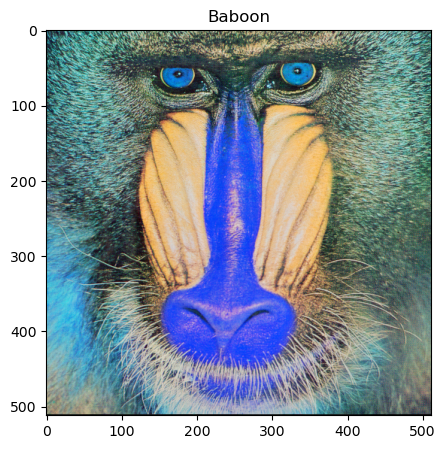

In [4]:
img_color = cv2.imread('../imagens/baboon.png', cv2.IMREAD_COLOR)

#cv2_imshow(img_color)
plot_img_cv2(img_color, "Baboon", 5, 5)

In [5]:
def negativo_image_color(img):
  # The input img is already a NumPy array, so no need to put it in a list
  H, W, C = img.shape
  neg_img = np.full((H, W, C), 255)
  negative_img = neg_img - img
  return negative_img

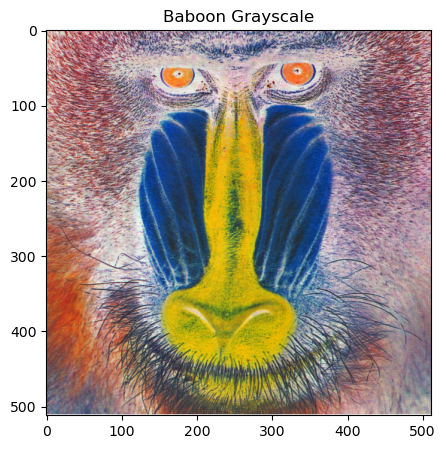

In [6]:
img_negative = negativo_image_color(img_color)

#cv2_imshow(img_negative)
plot_img_cv2(img_negative, "Baboon Grayscale", 5, 5)

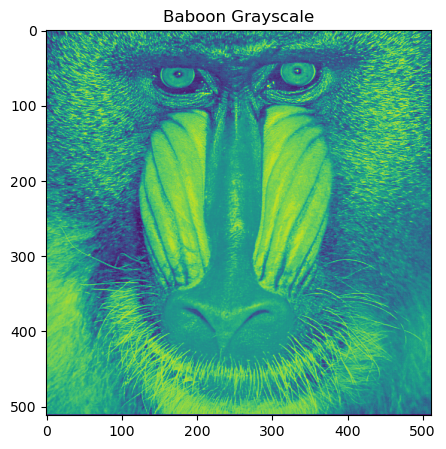

In [7]:
img_cinza = cv2.imread('../imagens/baboon.png', cv2.IMREAD_GRAYSCALE)

#cv2_imshow(img_cinza)
plot_img_cv2(img_cinza, "Baboon Grayscale", 5, 5)

In [8]:
def negativo_image_grayscale(img):
  neg_img = np.full(img.shape, 255)
  negative_img = neg_img - img
  return negative_img

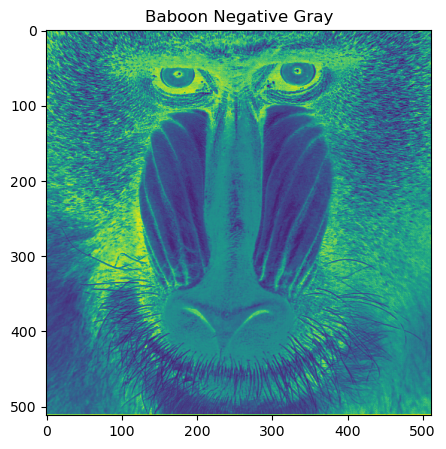

In [9]:
img_negative_grayscale = negativo_image_grayscale(img_cinza)

plot_img_cv2(img_negative_grayscale, "Baboon Negative Gray", 5, 5)

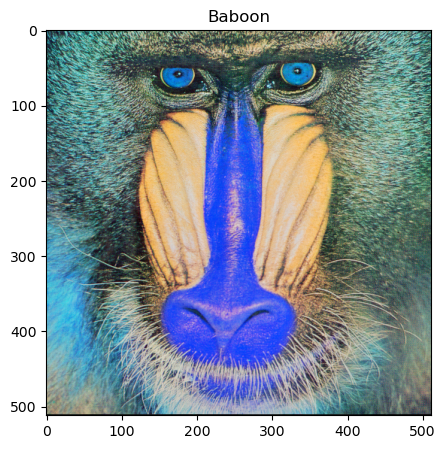

In [10]:
img_color = cv2.imread("../imagens/baboon.png", cv2.IMREAD_COLOR)

plot_img_cv2(img_color, "Baboon", 5, 5)

### Translação de uma imagem

In [11]:
def simples_translacao(img, trX, trY):
  # Codigo aqui
  H, W, C = img.shape

  imagem_transladada = np.zeros((H, W, C))

  for a in range(H):
    for b in range(W):
      if(((a + trY) > H-1) or ((b + trX) > W - 1)):
        continue

      imagem_transladada[a + trY, b + trX, :] = img[a, b, :]

  return imagem_transladada

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


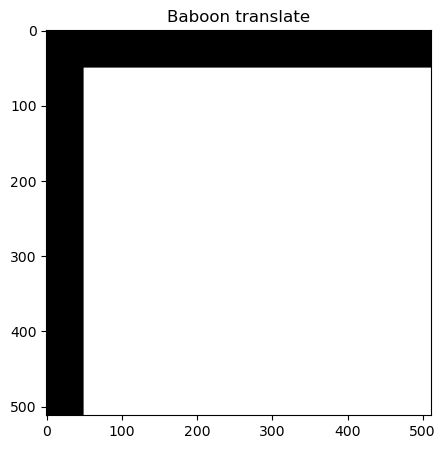

In [12]:
trImg = simples_translacao(img_color, 50, 50)

#cv2_imshow(trImg)
plot_img_cv2(trImg, "Baboon translate", 5, 5)

In [13]:
#img_gray_scale = simples_translacao(img_cinza, 50, 50)

#cv2_imshow(img_gray_scale)

# Criar uma função que le imagem em escala de cinza e colorida que faça translacao

In [14]:
def translacao_warpAffine(img, trX, trY):
  if len(img.shape) == 3: # Color image
    H, W, _ = img.shape
  else: # Grayscale image
    H, W = img.shape

  matriz_translacao = np.float32([[1, 0, trX], [0, 1, trY]])

  img_transladada = cv2.warpAffine(img, matriz_translacao, (W, H))

  return img_transladada

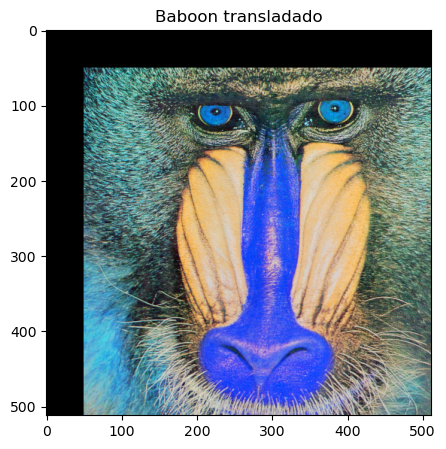

In [15]:
imagem_transladada_warpAffine = translacao_warpAffine(img_color, 50, 50)

#cv2_imshow(imagem_transladada_warpAffine)
plot_img_cv2(imagem_transladada_warpAffine, "Baboon transladado", 5, 5)

### Resize de uma imagem

In [16]:
def resize_image(img, factor_x, factor_y):
  H, W, C = img.shape

  H_new = int(H * factor_y)
  W_new = int(W * factor_x)

  img_resized = np.full((H_new, W_new, C), 0)

  for y in range(H_new):
    for x in range(W_new):
      y_new = int(y / factor_y)
      x_new = int(x / factor_x)
      img_resized[y, x, :] = img[y_new, x_new, :]

  return img_resized

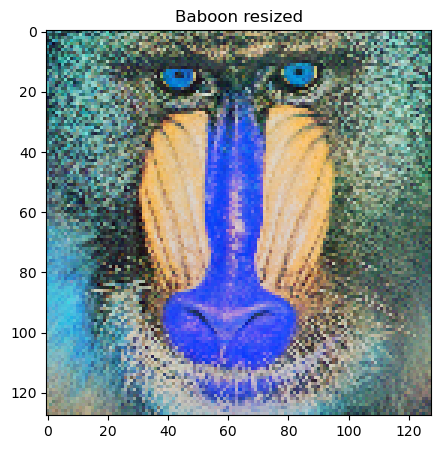

In [17]:
img_resized = resize_image(img_color, 0.25, 0.25)

#cv2_imshow(img_resized)
plot_img_cv2(img_resized, "Baboon resized", 5, 5)

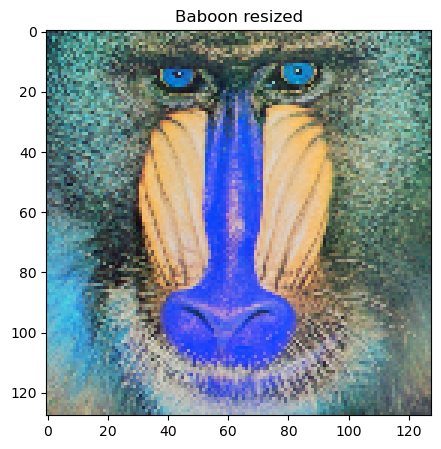

In [18]:
# Código com a opencv
factor_x, factor_y = 0.25, 0.25
img_resized_cv = cv2.resize(img_color, None, fx=factor_x, fy=factor_y)

#cv2_imshow(img_resized_cv)
plot_img_cv2(img_resized_cv, "Baboon resized", 5, 5)

#### Reflexão de uma imagem

In [19]:
def reflexao_imagem(img):
  # Digite o codigo aqui
  pass

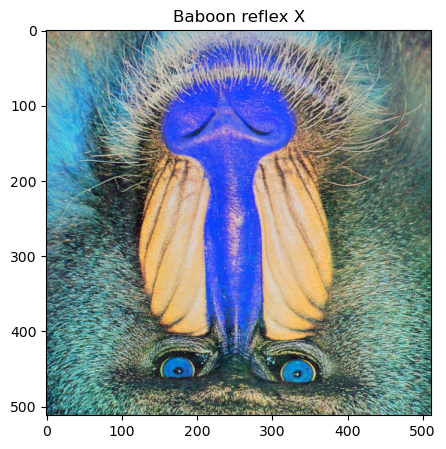

In [20]:
img_reflex_X = np.flip(img_color, axis=0)# Eixo vertical
img_reflex_Y = np.flip(img_color, axis=1)# Eixo horizontal

#cv2_imshow(img_reflex_X)
plot_img_cv2(img_reflex_X, "Baboon reflex X", 5, 5)

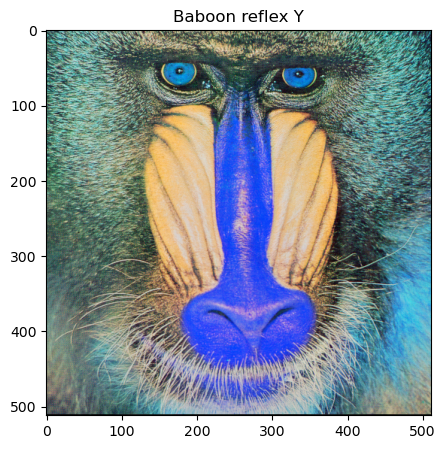

In [21]:
#cv2_imshow(img_reflex_Y)
plot_img_cv2(img_reflex_Y, "Baboon reflex Y", 5, 5)

### Rotação geral

In [22]:
def rotacao_geral(img, angulo_rotacao):
  H, W, C = img.shape

  img_rotacionada = np.zeros((H, W, C))
  M = cv2.getRotationMatrix2D(((W-1)/2, (H-1)/2), angulo_rotacao, 1.0) # Added scale factor (1.0) and corrected center
  img_rotacionada = cv2.warpAffine(img, M, (W, H))

  return img_rotacionada

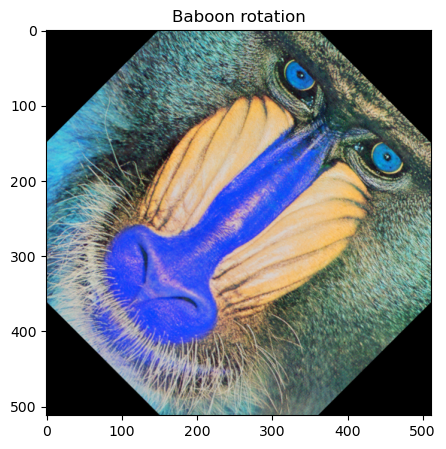

In [23]:
img_rotacao_completa = rotacao_geral(img_color, -45)

#cv2_imshow(img_rotacao_completa)
plot_img_cv2(img_rotacao_completa, "Baboon rotation", 5, 5)

#### Equalização de uma imagem a partir do histograma

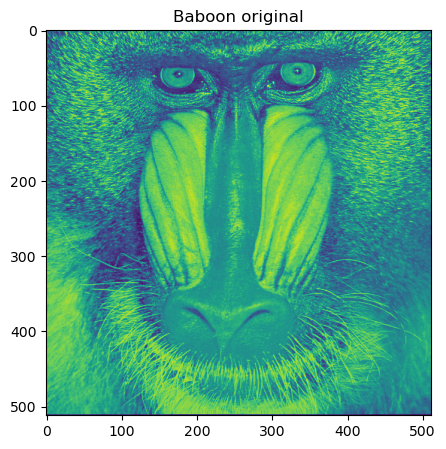

In [24]:
im_path = "../imagens/baboon.png"
img = cv2.imread(im_path)
src = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
dst = cv2.equalizeHist(src)
#cv2_imshow(src)
#cv2_imshow(dst)
plot_img_cv2(src, "Baboon original", 5, 5)

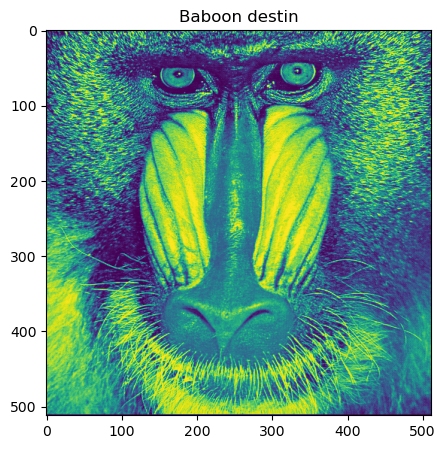

In [25]:
plot_img_cv2(dst, "Baboon destin", 5, 5)